In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sesilipirtskhalava/frangieh-dataset/frangieh.h5ad


## GEARS benchmark — frangieh IFNγ dataset
Evaluates GEARS against a simple average-perturbation baseline on the Frangieh co-culture single-gene perturbation dataset.

- Dataset: ~43 432 cells · 5 124 genes · 212 single-gene perturbations
- Task: predict gene expression for held-out single-gene perturbations
- Split: random 143 / 16 / 53 train / val / test across perturbations

## 1. Environment setup

In [2]:
%%capture
# Install required packages (output suppressed)
!pip install -q scanpy python-igraph louvain
!pip install -q torch-geometric anndata pytorch-lightning
!pip install -q cell-gears

In [3]:
import scanpy as sc
import random
import numpy as np
import pandas as pd
import torch
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Compatibility patch required by some GEARS versions
pd.Series.nonzero = lambda self: self.to_numpy().nonzero()

from gears import PertData, GEARS

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} | GPU available: {torch.cuda.is_available()} | device: {DEVICE}")

PyTorch 2.10.0+cu128 | GPU available: True | device: cuda


## 2. Loading the data and processing

In [4]:
from gears import PertData

pert_data = PertData("./data")

pert_data.adata = sc.read_h5ad(
    "/kaggle/input/datasets/sesilipirtskhalava/frangieh-dataset/frangieh.h5ad"
)

print(pert_data.adata)

Downloading...
100%|██████████| 9.46M/9.46M [00:00<00:00, 31.5MiB/s]


AnnData object with n_obs × n_vars = 110188 × 5124
    obs: 'gene', 'condition', 'perturbation', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_5000'
    uns: 'hvg', 'log1p'
    layers: 'counts', 'logNor'


In [6]:
# Keeping only IFNγ context
adata = pert_data.adata.copy()

ifng_adata = adata[
    adata.obs["condition"] == "IFNγ"
].copy()

print(ifng_adata.shape)
print(ifng_adata.obs["condition"].value_counts())
print(ifng_adata.obs["gene"].value_counts().head())


(43432, 5124)
condition
IFNγ    43432
Name: count, dtype: int64
gene
CTRL        789
MFGE8       341
SLC22A18    325
FGFR1       316
ACTA2       311
Name: count, dtype: int64


In [ ]:
# Adding gene_name column required by GEARS
ifng_adata.var["gene_name"] = ifng_adata.var_names.astype(str)

print(ifng_adata.var.columns)
print(ifng_adata.var[["gene_name"]].head())

In [11]:
# GEARS expects obs["condition"] = perturbation identity
ifng_adata.obs["condition"] = ifng_adata.obs["perturbation"].astype(str)

# GEARS expects control to be named ctrl
ifng_adata.obs["condition"] = ifng_adata.obs["condition"].replace({
    "control": "ctrl",
    "Control": "ctrl",
    "CTRL": "ctrl"
})

# GEARS requires cell_type column
ifng_adata.obs["cell_type"] = "melanoma_IFNg"

print(ifng_adata.obs[["perturbation", "condition", "cell_type"]].head())
print(ifng_adata.obs["condition"].value_counts().head())

              perturbation condition      cell_type
Cell_barcodes                                      
CELL_81293             A2M       A2M  melanoma_IFNg
CELL_60075             A2M       A2M  melanoma_IFNg
CELL_74837             A2M       A2M  melanoma_IFNg
CELL_110999            A2M       A2M  melanoma_IFNg
CELL_60110             A2M       A2M  melanoma_IFNg
condition
ctrl        789
MFGE8       341
SLC22A18    325
FGFR1       316
ACTA2       311
Name: count, dtype: int64


In [27]:
from scipy import sparse

if not sparse.issparse(ifng_adata.X):
    ifng_adata.X = sparse.csr_matrix(ifng_adata.X)

print(type(ifng_adata.X))

<class 'scipy.sparse._csr.csr_matrix'>


In [28]:
pert_data_frangieh = PertData("./data")

pert_data_frangieh.new_data_process(
    dataset_name="frangieh_ifng_de_sparse",
    adata=ifng_adata,
    skip_calc_de=False
)

Found local copy...
Found local copy...
Creating pyg object for each cell in the data...
Creating dataset file...
  0%|          | 0/212 [00:00<?, ?it/s]

A2M


  1%|          | 2/212 [00:02<03:42,  1.06s/it]

ACTA2


  3%|▎         | 6/212 [00:08<04:49,  1.40s/it]

...

 95%|█████████▌| 202/212 [04:00<00:11,  1.18s/it]

TTLL1


 97%|█████████▋| 205/212 [04:04<00:07,  1.11s/it]

UCN2


100%|██████████| 212/212 [04:10<00:00,  1.18s/it]
Done!
Saving new dataset pyg object at ./data/frangieh_ifng_de_sparse/data_pyg/cell_graphs.pkl
Done!


## 3. Train / val / test split

In [29]:
# Creating perturbation-level split
all_perturbations = sorted([
    p for p in ifng_adata.obs["condition"].unique()
    if p != "ctrl"
])

train_val_perturbations, test_perturbations = train_test_split(
    all_perturbations,
    test_size=0.25,
    random_state=SEED,
    shuffle=True
)

train_perturbations, val_perturbations = train_test_split(
    train_val_perturbations,
    test_size=0.1,
    random_state=SEED,
    shuffle=True
)

print("Total perturbations:", len(all_perturbations))
print("Train:", len(train_perturbations))
print("Val:", len(val_perturbations))
print("Test:", len(test_perturbations))

Total perturbations: 211
Train: 142
Val: 16
Test: 53


In [30]:
# Assigning manual perturbation-level split to GEARS
pert_data_frangieh.split = "manual_random_single_pert"

pert_data_frangieh.set2conditions = {
    "train": train_perturbations + ["ctrl"],
    "val": val_perturbations,
    "test": test_perturbations,
}

print(pert_data_frangieh.set2conditions.keys())
print("Train example:", pert_data_frangieh.set2conditions["train"][:5])
print("Val example:", pert_data_frangieh.set2conditions["val"][:5])
print("Test example:", pert_data_frangieh.set2conditions["test"][:5])

dict_keys(['train', 'val', 'test'])
Train example: ['HLA-B', 'CITED1', 'MT2A', 'CD58', 'VAT1']
Val example: ['DLL3', 'DDX17', 'SMAD4', 'ILF2', 'P2RX4']
Test example: ['CTSB', 'TGFB1', 'DDR1', 'TPRKB', 'CHCHD2']


In [31]:
import pickle

split_dict_path = "./data/frangieh_ifng_manual_split.pkl"

with open(split_dict_path, "wb") as f:
    pickle.dump(pert_data_frangieh.set2conditions, f)

print(split_dict_path)

./data/frangieh_ifng_manual_split.pkl


In [32]:
# Preparing GEARS split
pert_data_frangieh.prepare_split(
    split="custom",
    seed=SEED,
    split_dict_path=split_dict_path
)

pert_data_frangieh.get_dataloader(
    batch_size=32,
    test_batch_size=32
)

Creating dataloaders....
Done!


## 4. Ground-truth centroids and baseline

In [38]:
# Ground-truth centroids and average perturbation baseline

X = ifng_adata.X.toarray() if hasattr(ifng_adata.X, "toarray") else ifng_adata.X

gene_names = ifng_adata.var_names
conditions = ifng_adata.obs["condition"].values

pert_mask = conditions != "ctrl"

df_pert = pd.DataFrame(
    X[pert_mask],
    columns=gene_names
)

df_pert["condition"] = conditions[pert_mask]

ground_truth_centroids = (
    df_pert.groupby("condition")[gene_names]
    .mean()
)

# Reference / baseline = average of training perturbation centroids
reference = ground_truth_centroids.loc[train_perturbations].mean(axis=0).values

print("Ground-truth centroids:", ground_truth_centroids.shape)
print("Reference vector shape:", reference.shape)

Ground-truth centroids: (212, 5124)
Reference vector shape: (5124,)


## 5. Train GEARS

In [33]:
gears_model = GEARS(
    pert_data_frangieh,
    device=DEVICE
)

gears_model.model_initialize(
    hidden_size=64
)

Downloading...
100%|██████████| 60.7M/60.7M [00:02<00:00, 29.9MiB/s]
Extracting tar file...
Done!


In [34]:
gears_model.train(
    epochs=20
)

Start Training...
Epoch 1 Step 1 Train Loss: 1.5349
Epoch 1 Step 51 Train Loss: 1.2940
Epoch 1 Step 101 Train Loss: 1.3130
Epoch 1 Step 151 Train Loss: 1.4662
Epoch 1 Step 201 Train Loss: 1.5215
Epoch 1 Step 251 Train Loss: 1.5484
Epoch 1 Step 301 Train Loss: 1.4395
Epoch 1 Step 351 Train Loss: 1.4292
Epoch 1 Step 401 Train Loss: 1.5249
Epoch 1 Step 451 Train Loss: 1.4630
Epoch 1 Step 501 Train Loss: 1.5272
Epoch 1 Step 551 Train Loss: 1.4857
Epoch 1 Step 601 Train Loss: 1.4808
Epoch 1 Step 651 Train Loss: 1.4122
Epoch 1 Step 701 Train Loss: 1.3651
Epoch 1 Step 751 Train Loss: 1.7673
Epoch 1 Step 801 Train Loss: 1.2940
Epoch 1 Step 851 Train Loss: 1.5301
Epoch 1 Step 901 Train Loss: 1.5354
Epoch 1: Train Overall MSE: 0.0082 Validation Overall MSE: 0.0068. 
Train Top 20 DE MSE: 0.0205 Validation Top 20 DE MSE: 0.0180. 
Epoch 2 Step 1 Train Loss: 1.3650
Epoch 2 Step 51 Train Loss: 1.4585
Epoch 2 Step 101 Train Loss: 1.4446
Epoch 2 Step 151 Train Loss: 1.5411
Epoch 2 Step 201 Train Loss: 

In [36]:
predictable_test_perturbations = [
    p for p in test_perturbations
    if p in gears_model.pert_list
]

missing_test_perturbations = [
    p for p in test_perturbations
    if p not in gears_model.pert_list
]

print("Original test perturbations:", len(test_perturbations))
print("Predictable test perturbations:", len(predictable_test_perturbations))
print("Missing from GEARS graph:", len(missing_test_perturbations))
print(missing_test_perturbations[:20])

Original test perturbations: 53
Predictable test perturbations: 40
Missing from GEARS graph: 13
['CDKN2A', 'CTSO', 'CDKN2B', 'CSPG4', 'NT5E', 'CDH19', 'LGALS3', 'C6orf226', 'JMJD7', 'HSPA1A', 'S100B', 'ENPP1', 'LGALS3BP']


## 6. Predict on test perturbations

In [37]:
test_input = [[p] for p in predictable_test_perturbations]

predictions = gears_model.predict(test_input)

print("Number of predictions:", len(predictions))
print("Example keys:", list(predictions.keys())[:10])

Number of predictions: 40
Example keys: ['CTSB', 'TGFB1', 'DDR1', 'TPRKB', 'CHCHD2', 'IDH2', 'RRS1', 'UBC', 'PFDN4', 'ISYNA1']


In [39]:
# GEARS predictions
gears_pred_dict = {}

for pert in predictable_test_perturbations:
    gears_pred_dict[pert] = predictions[pert]

# Average perturbation baseline
avg_pred_dict = {}

for pert in predictable_test_perturbations:
    avg_pred_dict[pert] = reference

# Ground truth
truth_dict = {}

for pert in predictable_test_perturbations:
    truth_dict[pert] = ground_truth_centroids.loc[pert].values

print("GEARS predictions:", len(gears_pred_dict))
print("Baseline predictions:", len(avg_pred_dict))
print("Ground truths:", len(truth_dict))

GEARS predictions: 40
Baseline predictions: 40
Ground truths: 40


## Evaluation

GEARS was evaluated on the held-out test perturbations. Due to limitations of the perturbation graph, predictions could be generated for 40 of the 53 test perturbations. All evaluation metrics were therefore computed on these 40 predictable perturbations.

The average perturbation baseline was defined as the mean centroid of all training perturbations and was used as a constant baseline prediction. The same vector was used as the reference for PearsonΔ calculations.

In [43]:
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# ----------------------------
# Per-perturbation metrics
# ----------------------------
rows = []

for pert in predictable_test_perturbations:

    y_true = truth_dict[pert]
    y_gears = gears_pred_dict[pert]
    y_avg = avg_pred_dict[pert]

    rows.append({
        "perturbation": pert,
        "gears_rmse": np.sqrt(mean_squared_error(y_true, y_gears)),
        "avg_rmse": np.sqrt(mean_squared_error(y_true, y_avg)),
        "gears_pearson": pearsonr(y_true, y_gears)[0],
        "avg_pearson": pearsonr(y_true, y_avg)[0],
        "gears_pearson_delta": pearsonr(
            y_true - reference,
            y_gears - reference
        )[0]
    })

results_df = pd.DataFrame(rows)


# ----------------------------
# Centroid accuracy
# ----------------------------
def centroid_accuracy(pred_dict, truth_dict):
    perts = list(pred_dict.keys())
    scores = []

    for p in perts:
        d_correct = np.linalg.norm(pred_dict[p] - truth_dict[p])

        d_others = [
            np.linalg.norm(pred_dict[p] - truth_dict[q])
            for q in perts
            if q != p
        ]

        scores.append(np.mean([d_correct < d for d in d_others]))

    return np.mean(scores)


# ----------------------------
# Aggregate summary table
# ----------------------------
summary_table = pd.DataFrame({
    "GEARS": {
        "RMSE": results_df["gears_rmse"].mean(),
        "Pearson (raw)": results_df["gears_pearson"].mean(),
        "Pearson (delta)": results_df["gears_pearson_delta"].mean(),
        "Centroid accuracy": centroid_accuracy(gears_pred_dict, truth_dict)
    },
    "Average perturbation baseline": {
        "RMSE": results_df["avg_rmse"].mean(),
        "Pearson (raw)": results_df["avg_pearson"].mean(),
        "Pearson (delta)": np.nan,
        "Centroid accuracy": centroid_accuracy(avg_pred_dict, truth_dict)
    }
})

print("=== Aggregate summary ===")
display(summary_table.round(4))


# ----------------------------
# Top 15 perturbations by GEARS Pearson
# ----------------------------
top15_table = (
    results_df
    .sort_values("gears_pearson", ascending=False)
    [
        [
            "perturbation",
            "gears_rmse",
            "avg_rmse",
            "gears_pearson",
            "avg_pearson",
            "gears_pearson_delta"
        ]
    ]
    .head(15)
    .round(4)
)

print("=== Top 15 perturbations by GEARS Pearson ===")
display(top15_table)

=== Aggregate summary ===


,GEARS,Average perturbation baseline
RMSE,0.0524,0.0421
Pearson (raw),0.9911,0.9939
Pearson (delta),-0.0014,NaN
Centroid accuracy,0.4923,0.5000


=== Top 15 perturbations by GEARS Pearson ===


,perturbation,gears_rmse,avg_rmse,gears_pearson,avg_pearson,gears_pearson_delta
29,WBP2,0.0400,0.0285,0.9952,0.9976,0.0276
38,SDC3,0.0403,0.0276,0.9950,0.9977,0.0116
1,TGFB1,0.0418,0.0302,0.9946,0.9972,-0.0035
8,PFDN4,0.0422,0.0311,0.9946,0.9971,0.0299
11,CCND2,0.0422,0.0313,0.9946,0.9970,0.0079
4,CHCHD2,0.0432,0.0301,0.9944,0.9973,0.0168
19,LRPAP1,0.0427,0.0301,0.9944,0.9972,0.0141
0,CTSB,0.0434,0.0302,0.9943,0.9973,-0.0153
5,IDH2,0.0437,0.0315,0.9943,0.9971,-0.0328
10,AGA,0.0431,0.0305,0.9943,0.9971,0.0378


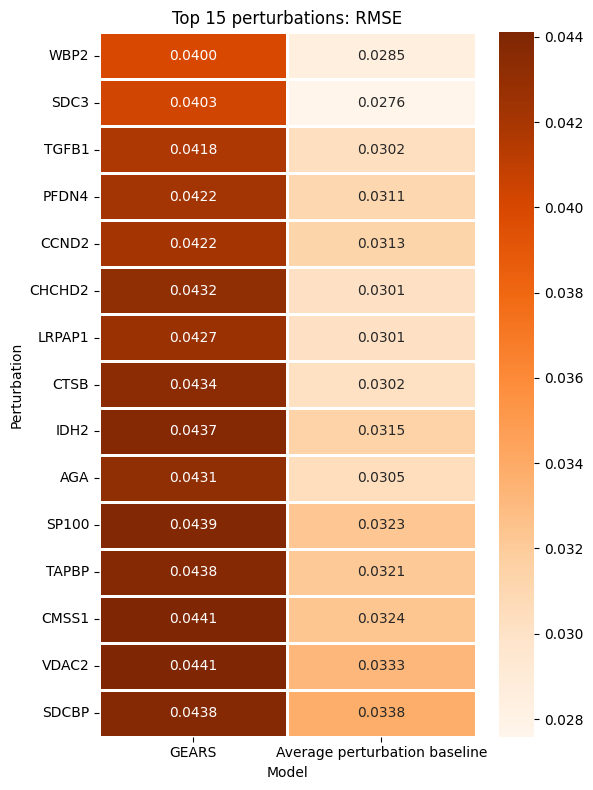

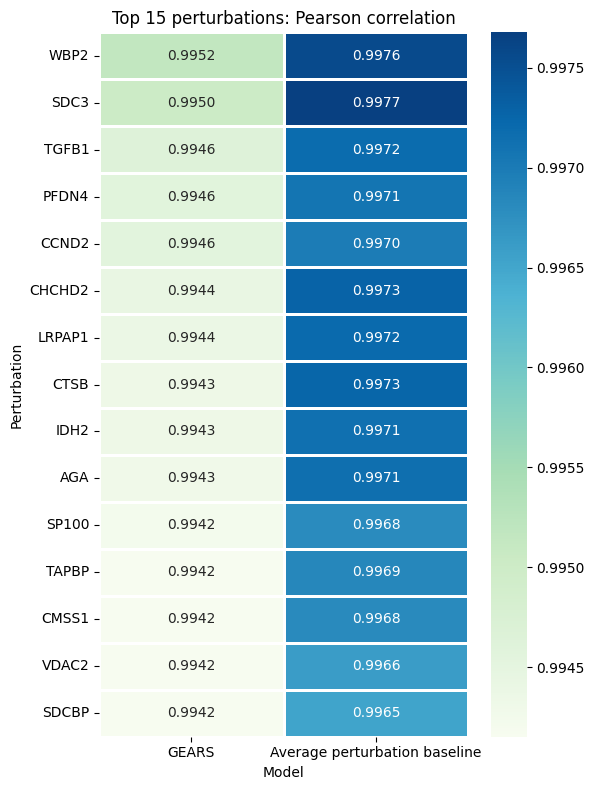

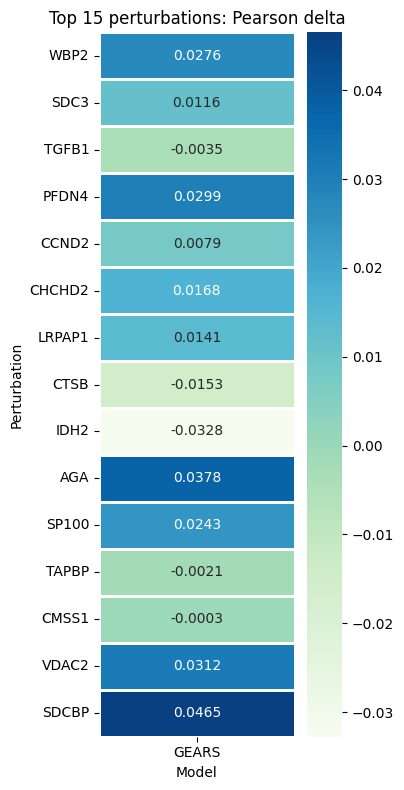

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
  
top15_perts = top15_table["perturbation"].tolist()

top15_metrics = results_df[
    results_df["perturbation"].isin(top15_perts)
].set_index("perturbation").loc[top15_perts]

rmse_heatmap = top15_metrics[
    ["gears_rmse", "avg_rmse"]
].rename(columns={
    "gears_rmse": "GEARS",
    "avg_rmse": "Average perturbation baseline"
})

plt.figure(figsize=(6, 8))
sns.heatmap(rmse_heatmap, annot=True, fmt=".4f", cmap="Oranges", linewidths=2, linecolor="white")
plt.title("Top 15 perturbations: RMSE")
plt.ylabel("Perturbation")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

pearson_heatmap = top15_metrics[
    ["gears_pearson", "avg_pearson"]
].rename(columns={
    "gears_pearson": "GEARS",
    "avg_pearson": "Average perturbation baseline"
})

plt.figure(figsize=(6, 8))
sns.heatmap(pearson_heatmap, annot=True, fmt=".4f", cmap="GnBu", linewidths=2, linecolor="white")
plt.title("Top 15 perturbations: Pearson correlation")
plt.ylabel("Perturbation")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

pearson_delta_heatmap = top15_metrics[
    ["gears_pearson_delta"]
].rename(columns={
    "gears_pearson_delta": "GEARS"
})

plt.figure(figsize=(4, 8))
sns.heatmap(pearson_delta_heatmap, annot=True, fmt=".4f", cmap="GnBu", linewidths=2, linecolor="white")
plt.title("Top 15 perturbations: Pearson delta")
plt.ylabel("Perturbation")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

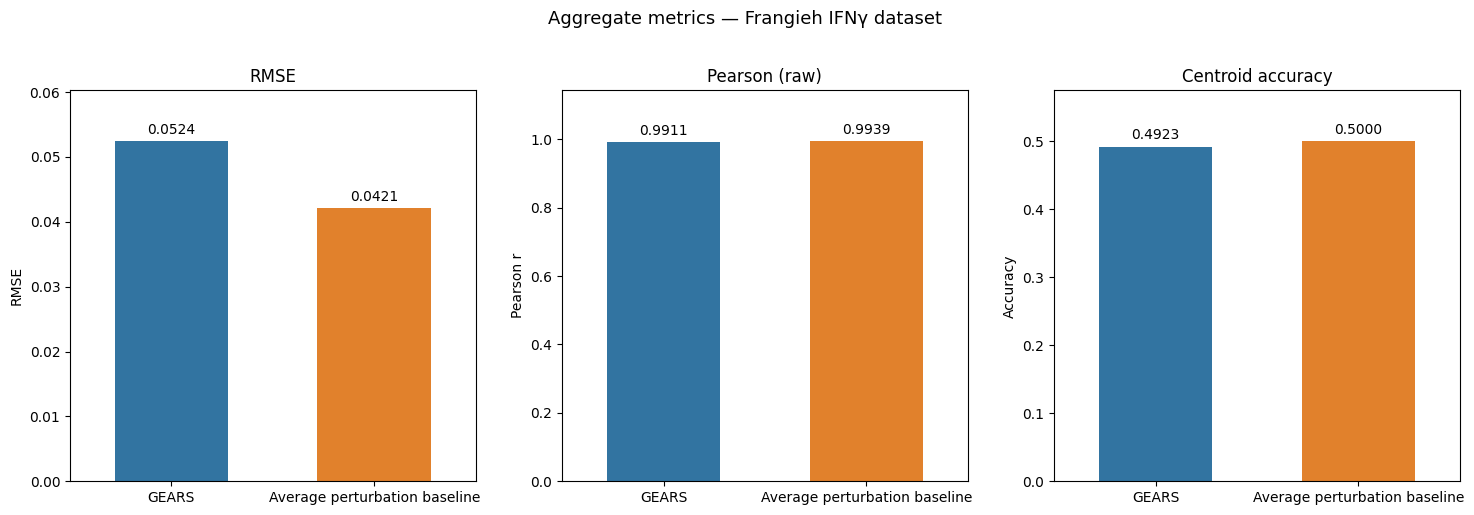

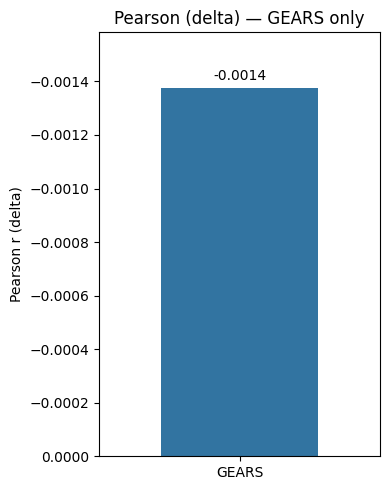

In [52]:
PALETTE = {
    "GEARS": "#1f77b4",
    "Average perturbation baseline": "#ff7f0e"
}

def slim_barplot(ax, data, x, y, palette, title, ylabel):
    sns.barplot(data=data, x=x, y=y, palette=palette, ax=ax)

    for bar in ax.patches:
        w = bar.get_width()
        bar.set_width(w * 0.7)
        bar.set_x(bar.get_x() + w * 0.15)

    ymax = data[y].dropna().max()
    ax.set_ylim(0, ymax * 1.15)

    for c in ax.containers:
        ax.bar_label(c, fmt="%.4f", padding=3)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")


summary_long = (
    summary_table.T
    .reset_index()
    .rename(columns={"index": "model"})
)

# ----------------------------
# RMSE, Pearson, Centroid Accuracy
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, ylabel in zip(
    axes,
    ["RMSE", "Pearson (raw)", "Centroid accuracy"],
    ["RMSE", "Pearson r", "Accuracy"]
):
    slim_barplot(
        ax,
        summary_long,
        x="model",
        y=metric,
        palette=PALETTE,
        title=metric,
        ylabel=ylabel
    )

plt.suptitle(
    "Aggregate metrics — Frangieh IFNγ dataset",
    fontsize=13,
    y=1.02
)

plt.tight_layout()
plt.show()


# ----------------------------
# Pearson delta (GEARS only)
# ----------------------------
gears_only = summary_long[
    summary_long["model"] == "GEARS"
]

fig, ax = plt.subplots(figsize=(4, 5))

slim_barplot(
    ax,
    gears_only,
    x="model",
    y="Pearson (delta)",
    palette={"GEARS": "#1f77b4"},
    title="Pearson (delta) — GEARS only",
    ylabel="Pearson r (delta)"
)

plt.tight_layout()
plt.show()